<a href="https://colab.research.google.com/github/misrori/ai/blob/2025/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ebben a blokkban nincs más dolgod, mint megnyomni a futtatás gombot. Ez automatikusan telepíti a szükséges csomagokat. ✅

In [ ]:
!git clone https://github.com/huggingface/diffusers.git
%cd diffusers
!pip install -e .
!pip install bitsandbytes accelerate
!pip install huggingface_hub

!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth.py

#GPU ellenőrzése és beállítása 🚀
Ebben a blokkban ellenőrizzük, hogy a Google Colabban GPU-t használunk-e. Ha nem, akkor manuálisan állítsd át:

jobb oldalt felül azt kell látni hogy T4


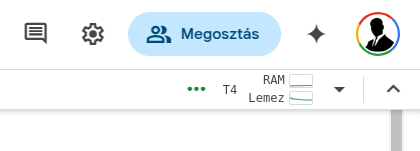

Ha nem ezt látod akkor futtatokörnyeztet majd futtatokörnyezet modositása és ott válaszd ki a T4 GPU-t






#Fájlok előkészítése 🖼️
Először is, a képeket a birme.net segítségével méretezzük át 512x512 pixeles négyzetekre. Az átméretezett fájlokat töltsd le a saját gépedre zippelve gyorsabb, majd feltöltjük ide az alábbi koddal, csak futtasd és válaszd ki a fájlokat (az összeset). ⬆️

In [ ]:
import os
from google.colab import files

# create a folder called kepek
if not os.path.exists("/content/kepek/"):
    os.mkdir("/content/kepek/")
os.chdir("/content/kepek/")
# upload files to kepek folder
uploaded = files.upload()
# move to kepek folder
os.chdir("/content/")

#Ezzel a kóddal megvizsgáljuk, hogy fent vannak-e a képeink itt az a fontos hogy lássad hogy ott kilistázza a képeket


In [ ]:

import os
os.listdir('/content/kepek/')

Indulhat a tréning! 🚀
Nyomd meg a futtatás gombot, és elindul a modell betanítása. Ez kb. 25-30 percig is eltarthat, légy türelmes! ⏳

In [ ]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth.py
!python train_dreambooth.py \
  --pretrained_model_name_or_path="stabilityai/stable-diffusion-2-1" \
  --instance_data_dir="/content/kepek" \
  --output_dir="/content/output_model" \
  --instance_prompt=f"a photo of goldhand" \
  --resolution=512 \
  --train_batch_size=1 \
  --learning_rate=5e-6 \
  --max_train_steps=800 \
  --gradient_accumulation_steps=1 \
  --use_8bit_adam

# Model feltöltés
#Hozz létre Hugging Face tokent? 🔑
A Hugging Face tokent arra használjuk, hogy hitelesítsük magunkat az API-jukon keresztül, és elérjük a modelleket, dataseteket vagy más erőforrásokat. Kövesd az alábbi lépéseket a saját tokened létrehozásához.

1️⃣ Regisztrálj vagy jelentkezz be a Hugging Face-re
Nyisd meg a Hugging Face weboldalát.
Ha még nincs fiókod, kattints a Sign Up gombra, és hozz létre egyet.
Ha már van fiókod, jelentkezz be a Log In gombra kattintva.


2️⃣ Navigálj a token beállításokhoz
A jobb felső sarokban kattints a profilképedre.
A lenyíló menüből válaszd a Settings opciót.
A bal oldali menüben keresd meg a Access Tokens fület.


3️⃣ Hozz létre egy új tokent
Kattints a New Token gombra.
Adj neki egy nevet (pl. my_token).
Válassz egy jogosultsági szintet:
Read – Csak olvasási jog, pl. modellek letöltéséhez.
Write – Olvasás és írás, ha például saját modelleket akarsz feltölteni.
Admin – Teljes jogosultság.
Kattints a Generate Token gombra.


4️⃣ Másold ki és mentsd el a tokent
A generált token megjelenik egy sárga dobozban.
FONTOS: Másold ki, és tárold biztonságosan, mert később már nem tudod újra megtekinteni!


In [ ]:
from huggingface_hub import login
from huggingface_hub import HfApi

# ide írd be a tokenedet, figyelj arra hogy idézőjelek között maradjon
hugging_face_token = "ide írd a tokened" #@param{type: 'string'}

login(hugging_face_token)

# ide pedig írd be a usernevedet amit  létrehoztál

felhasznalonevem = "ide írd a felhasznaloneved" #@param{type: 'string'}

api = HfApi()

api.create_repo(
    repo_id=f"{felhasznalonevem}/goldhandmodel",
    repo_type="model",
    private=False
)

api.upload_folder(
    folder_path="/content/output_model",
    repo_id=f"{felhasznalonevem}/goldhandmodel",
    repo_type="model"
)